In [51]:
# Colab Cell 1: setup + upload helpers + initial predict.py
# Run this cell first.

# 1) Install deps
!pip install --quiet numpy opencv-python-headless pillow scikit-learn scipy

# 2) Create folders
import os, textwrap, sys
os.makedirs("data/real", exist_ok=True)
os.makedirs("data/screen", exist_ok=True)
print("Created folders: data/real  data/screen")

# 3) Write initial predict.py (Laplacian heuristic smoke test)
predict_code = r'''
#!/usr/bin/env python3
import sys, time
import cv2
import numpy as np

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f"Failed to load image: {path}")
    return img

def laplacian_variance(gray):
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    return float(lap.var())

def map_lap_to_prob(lap_var):
    low = 5.0
    high = 150.0
    v = (lap_var - low) / (high - low)
    v = max(0.0, min(1.0, v))
    prob_screen = 1.0 - v
    return prob_screen

def predict(path, verbose=True):
    t0 = time.time()
    img = load_image(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lap_var = laplacian_variance(gray)
    prob = map_lap_to_prob(lap_var)
    latency_ms = (time.time() - t0) * 1000.0
    if verbose:
        print(f"DEBUG: image={path} shape={img.shape} lap_var={lap_var:.2f} latency_ms={latency_ms:.1f}")
    print(f"{prob:.4f}")
    return prob

if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python predict.py some_image.jpg")
        sys.exit(1)
    img_path = sys.argv[1]
    try:
        predict(img_path, verbose=True)
    except Exception as e:
        print("ERROR:", e)
        sys.exit(2)
'''
with open('predict.py','w') as f:
    f.write(predict_code)
print("Wrote predict.py (smoke-test)")

# 4) Upload helpers: upload files into data/real or data/screen
from google.colab import files
def upload_to(folder="data/real"):
    print(f"Upload files now. They will be saved to: {folder}")
    uploaded = files.upload()
    for name in uploaded.keys():
        dest = os.path.join(folder, name)
        with open(dest, "wb") as f:
            f.write(uploaded[name])
        print("Saved:", dest)
    return list(uploaded.keys())

print("\nHOW TO USE NEXT:")
print("1) Upload real photos: run -> upload_to('data/real')")
print("2) Upload screen photos: run -> upload_to('data/screen')")
print("3) Test predictor on one file: run -> !python3 predict.py data/real/yourfile.jpg")
print("When you finish this cell and upload at least one image to each folder, reply: done")


Created folders: data/real  data/screen
Wrote predict.py (smoke-test)

HOW TO USE NEXT:
1) Upload real photos: run -> upload_to('data/real')
2) Upload screen photos: run -> upload_to('data/screen')
3) Test predictor on one file: run -> !python3 predict.py data/real/yourfile.jpg
When you finish this cell and upload at least one image to each folder, reply: done


In [2]:
# example
upload_to('data/real')
upload_to('data/screen')


Upload files now. They will be saved to: data/real


Saving real001.jpeg to real001.jpeg
Saving real002.jpeg to real002.jpeg
Saving real003.jpeg to real003.jpeg
Saving real004.jpeg to real004.jpeg
Saving real005.jpeg to real005.jpeg
Saving real006.jpeg to real006.jpeg
Saving real007.jpeg to real007.jpeg
Saving real008.jpeg to real008.jpeg
Saving real009.jpeg to real009.jpeg
Saving real010.jpeg to real010.jpeg
Saving real011.jpeg to real011.jpeg
Saving real012.jpeg to real012.jpeg
Saving real013.jpeg to real013.jpeg
Saving real014.jpeg to real014.jpeg
Saving real015.jpeg to real015.jpeg
Saving real016.jpeg to real016.jpeg
Saving real017.jpeg to real017.jpeg
Saving real018.jpeg to real018.jpeg
Saving real019.jpeg to real019.jpeg
Saving real020.jpeg to real020.jpeg
Saving real021.jpeg to real021.jpeg
Saving real022.jpeg to real022.jpeg
Saving real023.jpeg to real023.jpeg
Saving real024.jpeg to real024.jpeg
Saving real025.jpeg to real025.jpeg
Saving real026.jpeg to real026.jpeg
Saving real027.jpeg to real027.jpeg
Saving real028.jpeg to real0

Saving screen001.jpeg to screen001.jpeg
Saving screen002.jpeg to screen002.jpeg
Saving screen003.jpeg to screen003.jpeg
Saving screen004.jpeg to screen004.jpeg
Saving screen005.jpeg to screen005.jpeg
Saving screen006.jpeg to screen006.jpeg
Saving screen007.jpeg to screen007.jpeg
Saving screen008.jpeg to screen008.jpeg
Saving screen009.jpeg to screen009.jpeg
Saving screen010.jpeg to screen010.jpeg
Saving screen011.jpeg to screen011.jpeg
Saving screen012.jpeg to screen012.jpeg
Saving screen013.jpeg to screen013.jpeg
Saving screen014.jpeg to screen014.jpeg
Saving screen015.jpeg to screen015.jpeg
Saving screen016.jpeg to screen016.jpeg
Saving screen017.jpeg to screen017.jpeg
Saving screen018.jpeg to screen018.jpeg
Saving screen019.jpeg to screen019.jpeg
Saving screen020.jpeg to screen020.jpeg
Saving screen021.jpeg to screen021.jpeg
Saving screen022.jpeg to screen022.jpeg
Saving screen023.jpeg to screen023.jpeg
Saving screen024.jpeg to screen024.jpeg
Saving screen025.jpeg to screen025.jpeg


['screen001.jpeg',
 'screen002.jpeg',
 'screen003.jpeg',
 'screen004.jpeg',
 'screen005.jpeg',
 'screen006.jpeg',
 'screen007.jpeg',
 'screen008.jpeg',
 'screen009.jpeg',
 'screen010.jpeg',
 'screen011.jpeg',
 'screen012.jpeg',
 'screen013.jpeg',
 'screen014.jpeg',
 'screen015.jpeg',
 'screen016.jpeg',
 'screen017.jpeg',
 'screen018.jpeg',
 'screen019.jpeg',
 'screen020.jpeg',
 'screen021.jpeg',
 'screen022.jpeg',
 'screen023.jpeg',
 'screen024.jpeg',
 'screen025.jpeg',
 'screen026.jpeg',
 'screen027.jpeg',
 'screen028.jpeg',
 'screen029.jpeg',
 'screen030.jpeg',
 'screen031.jpeg',
 'screen032.jpeg',
 'screen033.jpeg',
 'screen034.jpeg',
 'screen035.jpeg',
 'screen036.jpeg',
 'screen037.jpeg',
 'screen038.jpeg',
 'screen039.jpeg',
 'screen040.jpeg',
 'screen041.jpeg',
 'screen042.jpeg',
 'screen043.jpeg',
 'screen044.jpeg',
 'screen045.jpeg',
 'screen046.jpeg',
 'screen047.jpeg',
 'screen048.jpeg',
 'screen049.jpeg',
 'screen050.jpeg',
 'screen051.jpeg',
 'screen052.jpeg',
 'screen053.

In [52]:
# Colab Cell 2: extract features from data/real and data/screen -> features.csv
# Run this cell after you have uploaded images into data/real and data/screen.

import os, cv2, time, math
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
from scipy import fftpack

def list_images(folder):
    exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
    files = []
    for e in exts:
        files += glob(os.path.join(folder, e))
    return sorted(files)

def global_laplacian(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def patch_laplacian_stats(gray, patch=64):
    h,w = gray.shape
    vals = []
    for y in range(0, h, patch):
        for x in range(0, w, patch):
            p = gray[y:y+patch, x:x+patch]
            if p.size == 0: continue
            vals.append(float(cv2.Laplacian(p, cv2.CV_64F).var()))
    if len(vals)==0:
        return 0.0,0.0,0.0
    arr = np.array(vals)
    return float(np.percentile(arr,10)), float(np.percentile(arr,50)), float(np.percentile(arr,90))

def fft_mid_high_ratio(gray):
    # downsample for speed if large
    sh = gray.shape
    if max(sh) > 512:
        scale = 512.0 / max(sh)
        gray = cv2.resize(gray, (int(sh[1]*scale), int(sh[0]*scale)), interpolation=cv2.INTER_AREA)
    f = fftpack.fft2(gray)
    fshift = fftpack.fftshift(f)
    mag = np.abs(fshift)
    total = mag.sum() + 1e-9
    cy, cx = mag.shape[0]//2, mag.shape[1]//2
    r = min(mag.shape)//8
    yy,xx = np.ogrid[:mag.shape[0], :mag.shape[1]]
    dist = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    low_mask = dist <= r
    mid_mask = (dist > r) & (dist <= r*3)
    high_mask = dist > r*3
    mid = mag[mid_mask].sum()
    high = mag[high_mask].sum()
    # ratio of mid+high to total and high/(mid+high)
    return float((mid+high)/total), float(high/(mid+1e-9))

def saturation_variance(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    sat = hsv[:,:,1].astype(np.float32)
    return float(np.var(sat))

def edge_density(gray):
    edges = cv2.Canny(gray, 100, 200)
    return float(edges.sum() / (255.0 * gray.size))

def specular_count(bgr):
    # count very bright small regions in V channel
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:,:,2]
    _,th = cv2.threshold(v, 240, 255, cv2.THRESH_BINARY)
    # find contours and count small bright spots
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    count = 0
    for c in cnts:
        area = cv2.contourArea(c)
        if 5 < area < 2000:
            count += 1
    return float(count)

def extract_features(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError("Failed to read " + path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    feats = {}
    feats['path'] = path
    feats['h'] = bgr.shape[0]
    feats['w'] = bgr.shape[1]
    feats['global_lap'] = global_laplacian(gray)
    p10,p50,p90 = patch_laplacian_stats(gray, patch=64)
    feats['patch_lap_p10'] = p10
    feats['patch_lap_p50'] = p50
    feats['patch_lap_p90'] = p90
    midhigh, high_ratio = fft_mid_high_ratio(gray)
    feats['fft_midhigh_ratio'] = midhigh
    feats['fft_high_ratio'] = high_ratio
    feats['sat_var'] = saturation_variance(bgr)
    feats['edge_density'] = edge_density(gray)
    feats['specular_count'] = specular_count(bgr)
    return feats

# gather files
real_files = list_images("data/real")
screen_files = list_images("data/screen")
print(f"Found {len(real_files)} real images, {len(screen_files)} screen images")

rows = []
for p in tqdm(real_files, desc="real"):
    try:
        f = extract_features(p)
        f['label'] = 0
        rows.append(f)
    except Exception as e:
        print("ERR", p, e)

for p in tqdm(screen_files, desc="screen"):
    try:
        f = extract_features(p)
        f['label'] = 1
        rows.append(f)
    except Exception as e:
        print("ERR", p, e)

df = pd.DataFrame(rows)
# reorder columns
cols = ['path','label','h','w','global_lap','patch_lap_p10','patch_lap_p50','patch_lap_p90',
        'fft_midhigh_ratio','fft_high_ratio','sat_var','edge_density','specular_count']
df = df[cols]
df.to_csv("features.csv", index=False)
print("Wrote features.csv with", len(df), "rows")
display(df.head())
print("\nQuick stats:")
print(df.groupby('label').agg({'path':'count','global_lap':['mean','std'],'fft_midhigh_ratio':'mean'}))


Found 60 real images, 60 screen images


screen: 100%|██████████| 60/60 [00:06<00:00,  9.20it/s]

Wrote features.csv with 120 rows


,path,label,h,w,global_lap,patch_lap_p10,patch_lap_p50,patch_lap_p90,fft_midhigh_ratio,fft_high_ratio,sat_var,edge_density,specular_count
0,data/real/real001.jpeg,0,1280,720,1017.469851,0.613623,208.936070,3394.440221,0.723406,1.165023,2013.951416,0.078219,135.0
1,data/real/real002.jpeg,0,1280,720,70.087365,0.237305,1.834873,239.621672,0.630589,1.110615,3090.474365,0.014198,0.0
2,data/real/real003.jpeg,0,1280,720,432.110836,0.282178,204.723171,1228.511273,0.734211,1.073601,2232.850098,0.042233,7.0
3,data/real/real004.jpeg,0,720,1280,254.128985,2.090624,17.406667,872.560477,0.725156,1.038379,695.182617,0.034922,63.0
4,data/real/real005.jpeg,0,1280,720,564.054692,0.424609,95.659118,1474.024227,0.745141,1.574074,4619.844238,0.057908,8.0



Quick stats:
       path  global_lap             fft_midhigh_ratio
      count        mean         std              mean
label                                                
0        60  240.456479  238.529884          0.627164
1        60  127.377866  120.931261          0.606183


In [53]:
# Colab Cell 3: train classifier, evaluate, save model+scaler, write predict.py
# Run this cell after features.csv exists.

!pip install --quiet joblib

import os, joblib, time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# 1) Load features
df = pd.read_csv("features.csv")
# features we will use (fast to compute)
feature_cols = ['global_lap','patch_lap_p10','patch_lap_p50','patch_lap_p90',
                'fft_midhigh_ratio','fft_high_ratio','sat_var','edge_density','specular_count']
# ensure columns exist
for c in feature_cols:
    if c not in df.columns:
        raise RuntimeError(f"Missing feature column: {c}")

X = df[feature_cols].fillna(0.0).values
y = df['label'].values

print("Data shape:", X.shape, "Labels:", np.bincount(y.astype(int)))

# 2) Scale features (fit on full data for final model; CV uses pipeline below)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 3) Cross-validated predictions for metrics
clf = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(clf, X_scaled, y, cv=cv, method='predict')
y_proba = cross_val_predict(clf, X_scaled, y, cv=cv, method='predict_proba')[:,1]

# 4) Metrics
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_proba)
cm = confusion_matrix(y, y_pred)

print("\nCross-validated performance (5-fold):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("\nClassification report:")
print(classification_report(y, y_pred, digits=4))

# 5) Fit final model on all data and save scaler+model
clf_final = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
clf_final.fit(X_scaled, y)
os.makedirs("model", exist_ok=True)
joblib.dump(scaler, "model/scaler.joblib")
joblib.dump(clf_final, "model/model.joblib")
print("\nSaved scaler -> model/scaler.joblib")
print("Saved model  -> model/model.joblib")

# 6) Write production predict.py that extracts features and prints probability
predict_py = r'''
#!/usr/bin/env python3
import sys, time, os
import cv2
import numpy as np
import joblib
from scipy import fftpack

# load model and scaler
MODEL_PATH = os.path.join(os.path.dirname(__file__), "model", "model.joblib")
SCALER_PATH = os.path.join(os.path.dirname(__file__), "model", "scaler.joblib")
clf = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

def global_laplacian(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def patch_laplacian_stats(gray, patch=64):
    h,w = gray.shape
    vals = []
    for y in range(0, h, patch):
        for x in range(0, w, patch):
            p = gray[y:y+patch, x:x+patch]
            if p.size == 0: continue
            vals.append(float(cv2.Laplacian(p, cv2.CV_64F).var()))
    if len(vals)==0:
        return 0.0,0.0,0.0
    arr = np.array(vals)
    return float(np.percentile(arr,10)), float(np.percentile(arr,50)), float(np.percentile(arr,90))

def fft_mid_high_ratio(gray):
    sh = gray.shape
    if max(sh) > 512:
        scale = 512.0 / max(sh)
        gray = cv2.resize(gray, (int(sh[1]*scale), int(sh[0]*scale)), interpolation=cv2.INTER_AREA)
    f = fftpack.fft2(gray)
    fshift = fftpack.fftshift(f)
    mag = np.abs(fshift)
    total = mag.sum() + 1e-9
    cy, cx = mag.shape[0]//2, mag.shape[1]//2
    r = min(mag.shape)//8
    yy,xx = np.ogrid[:mag.shape[0], :mag.shape[1]]
    dist = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    low_mask = dist <= r
    mid_mask = (dist > r) & (dist <= r*3)
    high_mask = dist > r*3
    mid = mag[mid_mask].sum()
    high = mag[high_mask].sum()
    return float((mid+high)/total), float(high/(mid+1e-9))

def saturation_variance(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    sat = hsv[:,:,1].astype(np.float32)
    return float(np.var(sat))

def edge_density(gray):
    edges = cv2.Canny(gray, 100, 200)
    return float(edges.sum() / (255.0 * gray.size))

def specular_count(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:,:,2]
    _,th = cv2.threshold(v, 240, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    count = 0
    for c in cnts:
        area = cv2.contourArea(c)
        if 5 < area < 2000:
            count += 1
    return float(count)

def extract_features(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError("Failed to read " + path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    global_lap = global_laplacian(gray)
    p10,p50,p90 = patch_laplacian_stats(gray, patch=64)
    midhigh, high_ratio = fft_mid_high_ratio(gray)
    sat_var = saturation_variance(bgr)
    ed = edge_density(gray)
    spec = specular_count(bgr)
    feats = [global_lap, p10, p50, p90, midhigh, high_ratio, sat_var, ed, spec]
    return np.array(feats, dtype=np.float32).reshape(1, -1)

def predict(path, verbose=True):
    t0 = time.time()
    feats = extract_features(path)
    feats_scaled = scaler.transform(feats)
    prob = float(clf.predict_proba(feats_scaled)[0,1])
    latency_ms = (time.time() - t0) * 1000.0
    if verbose:
        print(f"DEBUG: image={path} prob_screen={prob:.4f} latency_ms={latency_ms:.1f}")
    print(f"{prob:.4f}")
    return prob

if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python predict.py some_image.jpg")
        sys.exit(1)
    img_path = sys.argv[1]
    try:
        predict(img_path, verbose=True)
    except Exception as e:
        print("ERROR:", e)
        sys.exit(2)
'''
with open('predict.py','w') as f:
    f.write(predict_py)
print("Wrote production predict.py")

# 7) Quick test on a few sample rows (if files exist)
sample_paths = df['path'].values[:4].tolist()
print("\nQuick test on up to 4 sample images (prints probability):")
for p in sample_paths:
    if os.path.exists(p):
        print("->", p)
        os.system(f"python3 predict.py \"{p}\"")
    else:
        print("Missing:", p)

print("\nDone. To test manually:")
print("!python3 predict.py data/real/real001.jpeg")
print("!python3 predict.py data/screen/screen001.jpeg")


Data shape: (120, 9) Labels: [60 60]

Cross-validated performance (5-fold):
Accuracy: 0.8250
Precision: 0.8545
Recall: 0.7833
F1: 0.8174
ROC AUC: 0.8722
Confusion matrix (rows=true, cols=pred):
[[52  8]
 [13 47]]

Classification report:
              precision    recall  f1-score   support

           0     0.8000    0.8667    0.8320        60
           1     0.8545    0.7833    0.8174        60

    accuracy                         0.8250       120
   macro avg     0.8273    0.8250    0.8247       120
weighted avg     0.8273    0.8250    0.8247       120


Saved scaler -> model/scaler.joblib
Saved model  -> model/model.joblib
Wrote production predict.py

Quick test on up to 4 sample images (prints probability):
-> data/real/real001.jpeg
-> data/real/real002.jpeg
-> data/real/real003.jpeg
-> data/real/real004.jpeg

Done. To test manually:
!python3 predict.py data/real/real001.jpeg
!python3 predict.py data/screen/screen001.jpeg


In [54]:
!python3 predict.py data/real/real001.jpeg

DEBUG: image=data/real/real001.jpeg prob_screen=0.1952 latency_ms=87.0
0.1952


In [55]:
!python3 predict.py data/screen/screen001.jpeg

DEBUG: image=data/screen/screen001.jpeg prob_screen=0.9070 latency_ms=185.0
0.9070


Data shape: (120, 9) Class counts: [60 60]
Train/val sizes: 96 24
Running RandomizedSearchCV for RandomForest (50 iterations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best RF params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None} best CV AUC: 0.8844444444444445

Running RandomizedSearchCV for LogisticRegression (20 iterations)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best LR params: {'penalty': 'l2', 'C': 0.1} best CV AUC: 0.8768888888888888

Selected best candidate: RandomForestClassifier
Calibration done.

Validation performance (after calibration):
Accuracy: 0.8750  Precision: 0.8462  Recall: 0.9167  F1: 0.8800  AUC: 0.9549  Brier: 0.0893
Confusion matrix:
 [[10  2]
 [ 1 11]]


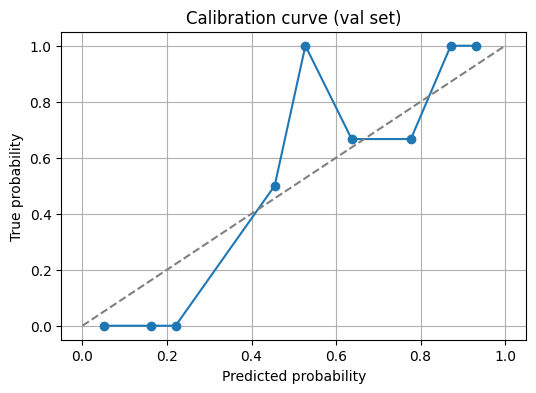

Best F1 threshold on val set: 0.471  F1: 0.9231
Saved scaler -> model/scaler.joblib
Saved calibrated model -> model/best_model.joblib

To use the calibrated model in predict.py, load 'model/best_model.joblib' and 'model/scaler.joblib',
call predict_proba(X_scaled) and return the probability (decimal). To apply a custom threshold, compare prob >= threshold.


In [56]:
# Colab Cell 4: Hyperparameter tuning + calibration + save model
# Run this after Cell 2 and Cell 3 (features.csv exists)

import os, joblib, numpy as np, pandas as pd, time
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, brier_score_loss)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1) Load features
df = pd.read_csv("features.csv")
feature_cols = ['global_lap','patch_lap_p10','patch_lap_p50','patch_lap_p90',
                'fft_midhigh_ratio','fft_high_ratio','sat_var','edge_density','specular_count']
X = df[feature_cols].fillna(0.0).values
y = df['label'].values.astype(int)
print("Data shape:", X.shape, "Class counts:", np.bincount(y))

# 2) Train/val split for final calibration and threshold selection (stratified)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
print("Train/val sizes:", X_train.shape[0], X_val.shape[0])

# 3) Scale features (fit scaler on training only)
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

# 4) Define candidate estimators and search spaces
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_param_dist = {
    'n_estimators': [50,100,200,400],
    'max_depth': [None, 8, 16, 32],
    'min_samples_leaf': [1,2,4,8],
    'max_features': ['sqrt','log2', 0.5, 0.8]
}

lr = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=42)
lr_param_dist = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2']
}

# 5) Randomized search for RF (fast) and LR (quick baseline)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running RandomizedSearchCV for RandomForest (50 iterations)...")
rs_rf = RandomizedSearchCV(rf, rf_param_dist, n_iter=50, scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1, verbose=1)
rs_rf.fit(X_train_s, y_train)
print("Best RF params:", rs_rf.best_params_, "best CV AUC:", rs_rf.best_score_)

print("\nRunning RandomizedSearchCV for LogisticRegression (20 iterations)...")
rs_lr = RandomizedSearchCV(lr, lr_param_dist, n_iter=20, scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1, verbose=1)
rs_lr.fit(X_train_s, y_train)
print("Best LR params:", rs_lr.best_params_, "best CV AUC:", rs_lr.best_score_)

# 6) Choose best estimator by CV AUC
best_candidate = rs_rf.best_estimator_ if rs_rf.best_score_ >= rs_lr.best_score_ else rs_lr.best_estimator_
print("\nSelected best candidate:", type(best_candidate).__name__)

# 7) Calibrate the selected estimator using validation set (Platt / isotonic)
# Use 'sigmoid' (Platt) for small datasets; isotonic if you have >200 val samples
calibrator = CalibratedClassifierCV(best_candidate, method='sigmoid', cv='prefit')
best_candidate.fit(X_train_s, y_train)  # fit on full training
calibrator.fit(X_val_s, y_val)          # calibrate on held-out validation
print("Calibration done.")

# 8) Evaluate on validation set
y_val_proba = calibrator.predict_proba(X_val_s)[:,1]
y_val_pred = (y_val_proba >= 0.5).astype(int)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_proba)
brier = brier_score_loss(y_val, y_val_proba)
cm = confusion_matrix(y_val, y_val_pred)

print("\nValidation performance (after calibration):")
print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}  Brier: {brier:.4f}")
print("Confusion matrix:\n", cm)

# 9) Calibration curve plot (optional)
try:
    prob_true, prob_pred = calibration_curve(y_val, y_val_proba, n_bins=10)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,4))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibrated')
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.title('Calibration curve (val set)')
    plt.grid(True)
    plt.show()
except Exception as e:
    print("Calibration plot failed:", e)

# 10) Threshold selection: show a few candidate thresholds and metrics
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
# compute F1 for thresholds
f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
print(f"Best F1 threshold on val set: {best_thresh:.3f}  F1: {f1s[best_idx]:.4f}")

# 11) Save calibrated model and scaler
os.makedirs("model", exist_ok=True)
joblib.dump(scaler, "model/scaler.joblib")
joblib.dump(calibrator, "model/best_model.joblib")
print("Saved scaler -> model/scaler.joblib")
print("Saved calibrated model -> model/best_model.joblib")

# 12) Print instructions for using calibrated model in predict.py
print("\nTo use the calibrated model in predict.py, load 'model/best_model.joblib' and 'model/scaler.joblib',")
print("call predict_proba(X_scaled) and return the probability (decimal). To apply a custom threshold, compare prob >= threshold.")


In [57]:
# Create results.csv by running predict.py on all images (run in Colab)
import glob, subprocess, csv, time, numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

def run_predict(path):
    proc = subprocess.run(["python3","predict.py", path], capture_output=True, text=True)
    out = [l for l in proc.stdout.splitlines() if l.strip()]
    if not out:
        return None, None
    try:
        # expects predict.py prints probability then label on separate lines
        prob = float(out[-2])
        label = int(out[-1])
        return prob, label
    except:
        # fallback: if predict.py prints only probability, return prob and binary pred by 0.5
        try:
            prob = float(out[-1])
            label = 1 if prob >= 0.5 else 0
            return prob, label
        except:
            return None, None

real_files = sorted(glob.glob("data/real/*"))
screen_files = sorted(glob.glob("data/screen/*"))
all_files = real_files + screen_files

rows = []
times = []
for p in all_files:
    t0 = time.time()
    prob, pred = run_predict(p)
    t1 = time.time()
    times.append((p, (t1-t0)*1000.0))
    true = 0 if "/real/" in p else 1
    rows.append((p, true, prob, pred))

# write CSV
with open("results.csv","w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["path","label","prob_screen","pred_label"])
    for path,label,prob,pred in rows:
        writer.writerow([path,label,prob if prob is not None else "", pred if pred is not None else ""])

# compute metrics ignoring missing
valid = [r for r in rows if r[2] is not None]
y_true = [r[1] for r in valid]
y_pred = [r[3] for r in valid]
print("Evaluated images:", len(valid), "out of", len(all_files))
if len(valid)>0:
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
else:
    print("No valid predictions were produced. Check predict.py output format.")

lat_ms = np.array([t for _,t in times])
print("Median latency (ms):", np.median(lat_ms))
print("95th percentile latency (ms):", np.percentile(lat_ms,95))


Evaluated images: 120 out of 120
Accuracy: 0.8416666666666667
Confusion matrix:
 [[51  9]
 [10 50]]
Median latency (ms): 2397.0627784729004
95th percentile latency (ms): 3159.0486764907837


In [58]:
# Quick check
import os, pandas as pd
print("Exists:", os.path.exists("results.csv"))
if os.path.exists("results.csv"):
    df = pd.read_csv("results.csv")
    display(df.head())
    print("Rows:", len(df))


Exists: True


,path,label,prob_screen,pred_label
0,data/real/real001.jpeg,0,0.1350,0
1,data/real/real002.jpeg,0,0.0124,0
2,data/real/real003.jpeg,0,0.0045,0
3,data/real/real004.jpeg,0,0.2476,0
4,data/real/real005.jpeg,0,0.0005,0


Rows: 120


In [59]:
!python3 predict.py data/screen/screen001.jpeg

DEBUG: image=data/screen/screen001.jpeg prob_screen=0.9213 latency_ms=213.2
0.9213


In [62]:
!find . -type f | grep -E "predict.py|joblib|pkl"

./hn_logistic.pkl
./model/model.joblib
./model/best_model.joblib
./model/scaler.joblib
./predict.py


In [64]:
from google.colab import files


files.download("model/best_model.joblib")
files.download("model/scaler.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>